In [1]:
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")
from pathlib import Path

from scipy import stats
from pmdarima import auto_arima
from pmdarima.arima import ndiffs, nsdiffs

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
df = pd.read_csv('E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)

# Lấy chuỗi PM2.5 theo ngày
df_pm25 = df[['PM25']].resample('D').mean().asfreq('D')
df_pm25['PM25'] = df_pm25['PM25'].interpolate(limit_direction='both')


In [3]:

TRANSFORM = 'log'   # chọn 'identity' hoặc 'log' hoặc 'boxcox'

def transform_series(s, method='identity'):
    if method=='identity':
        return s.copy(), None
    if method=='log':
        return np.log(s + 1e-6), None
    if method=='boxcox':
        y = s + 1e-6
        y2, lam = stats.boxcox(y)
        return pd.Series(y2, index=s.index), lam
    raise ValueError("Phương pháp transform không hợp lệ")

def inv_transform(s_t, method='identity', lam=None):
    if method=='identity': return s_t
    if method=='log': return np.exp(s_t) - 1e-6
    if method=='boxcox':
        try:
            return stats.inv_boxcox(s_t, lam)
        except Exception:
            if lam == 0:
                return np.exp(s_t) - 1e-6
            return np.power(s_t * lam + 1, 1/lam) - 1e-6
    raise ValueError("Phương pháp inverse không hợp lệ")

# Kiểm tra transform → inverse nhanh
y_sample = df_pm25['PM25'].dropna().iloc[:20]
y_tst, lam_test = transform_series(y_sample, method=TRANSFORM)
print("Sai số max khi transform→inv (20 mẫu đầu):", np.nanmax(np.abs(inv_transform(y_tst, TRANSFORM, lam_test) - y_sample)))


Sai số max khi transform→inv (20 mẫu đầu): 4.263256414560601e-14


In [4]:
# CELL 4: chia dữ liệu theo thời gian (80/20)
y = df_pm25['PM25'].dropna()
cutoff_test = int(len(y) * 0.8)

# Áp transform cho toàn bộ rồi cắt (để train/test cùng thang transform)
y_all_t, lam = transform_series(y, method=TRANSFORM)
y_train = y_all_t.iloc[:cutoff_test].copy()
y_test  = y_all_t.iloc[cutoff_test:].copy()

print("Train:", y_train.index.min(), "->", y_train.index.max(), "số bản ghi:", len(y_train))
print("Test :", y_test.index.min(), "->", y_test.index.max(), "số bản ghi:", len(y_test))


Train: 2023-01-01 00:00:00 -> 2024-08-06 00:00:00 số bản ghi: 584
Test : 2024-08-07 00:00:00 -> 2024-12-31 00:00:00 số bản ghi: 147


Kiểm ADF/KPSS trên y_train (thang gốc):
ADF stat: -5.8305 | p-value: 0.0000
Giá trị tới hạn: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}
=> stationary (không cần diff)
KPSS stat: 0.2720 | p-value: 0.1000
Giá trị tới hạn: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
=> stationary (không reject H0)
pmdarima gợi ý: d = 0 , D = 0 (m=7)


C:\Users\hungd\AppData\Local\Temp\ipykernel_16156\1559564086.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(series.dropna(), regression='c', nlags='auto')


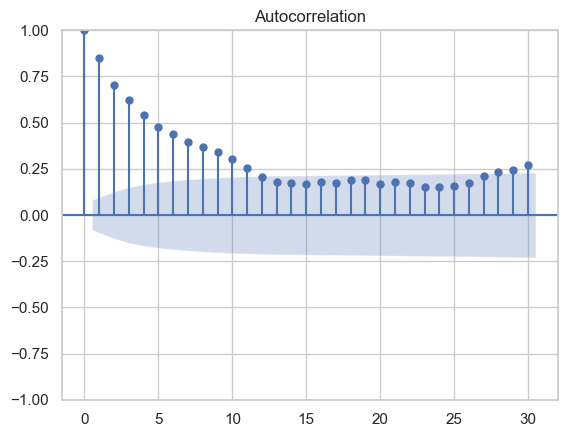

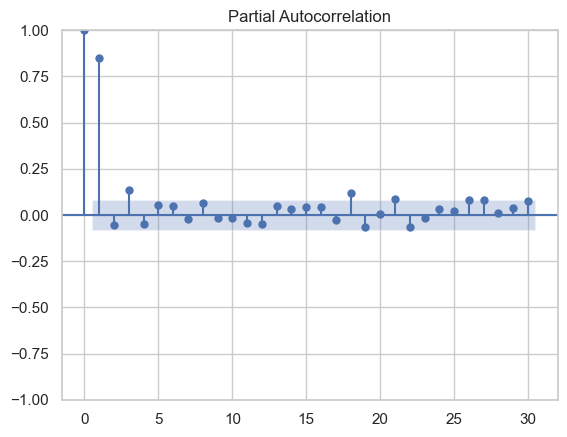

In [5]:
# CELL 5: kiểm ADF/KPSS để quyết differencing, vẽ ACF/PACF để gợi ý p/q
def adf_test(series):
    res = adfuller(series.dropna(), autolag='AIC')
    print("ADF stat: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Giá trị tới hạn:", res[4])
    print("=>", "stationary (không cần diff)" if res[1]<0.05 else "non-stationary (cần diff)")

def kpss_test(series):
    res = kpss(series.dropna(), regression='c', nlags='auto')
    print("KPSS stat: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Giá trị tới hạn:", res[3])
    print("=>", "non-stationary (reject H0)" if res[1]<0.05 else "stationary (không reject H0)")

# Dùng y_train (thang gốc) để kiểm
y_train_goc = y.iloc[:cutoff_test]
print("Kiểm ADF/KPSS trên y_train (thang gốc):")
adf_test(y_train_goc)
kpss_test(y_train_goc)

# pmdarima gợi ý d và D
d_suggest = ndiffs(y_train_goc, test='adf')
D_suggest = nsdiffs(y_train_goc, m=7, test='ch')
print("pmdarima gợi ý: d =", d_suggest, ", D =", D_suggest, "(m=7)")

# Vẽ ACF và PACF để tham khảo (gốc)
plot_acf(y_train_goc.dropna(), lags=30); plt.show()
plot_pacf(y_train_goc.dropna(), lags=30, method='ywm'); plt.show()


In [6]:
# CELL 6: chạy auto_arima để gợi ý order (p,d,q) và seasonal_order

step = auto_arima(y_train, seasonal=True, m=30, trace=False,
                  max_p=7, max_q=4, max_P=2, max_Q=2,
                  d=None, D=None, stepwise=True, error_action='ignore', suppress_warnings=True)
order0 = step.order
seasonal0 = step.seasonal_order
print("auto_arima gợi ý:", order0, seasonal0)

# Tạo một neighborhood nhỏ quanh đề xuất để thử nghiệm
p0,d0,q0 = order0
p_range = list(range(max(0,p0-1), p0+2))
q_range = list(range(max(0,q0-1), q0+2))
candidates = [(p,d0,q) for p in p_range for q in q_range]
print("Các candidate sẽ thử:", candidates)


auto_arima gợi ý: (1, 1, 2) (0, 0, 1, 30)
Các candidate sẽ thử: [(0, 1, 1), (0, 1, 2), (0, 1, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (2, 1, 1), (2, 1, 2), (2, 1, 3)]


In [7]:
# 1) Kỳ nghỉ
holiday_periods = {
    'Tết 2023': ('2023-01-20', '2023-01-26'),
    'Lễ 30/4-1/5 2023': ('2023-04-29', '2023-05-03'),
    'Lễ 2/9 2023': ('2023-08-31', '2023-09-04'),
    'Tết Dương 2024': ('2023-12-30', '2024-01-01'),
    'Tết 2024': ('2024-02-08', '2024-02-14'),
    'Lễ 30/4-1/5 2024': ('2024-04-27', '2024-05-01'),
    'Lễ 2/9 2024': ('2024-08-31', '2024-09-03'),
}

# 2) Xây exog_df (daily)
#    - Pollutant: mean theo ngày
#    - Thời tiết: mưa dùng sum, rain_hours dùng sum, các biến khác dùng mean

pollutant_cols = ['PM10', 'NO2', 'SO2']
weather_cols    = ['Pressure', 'Temperature', 'Wind Speed', 'Precipitation', 'Relative Humidity']

pollutant_cols = [c for c in pollutant_cols if c in df.columns]
weather_cols   = [c for c in weather_cols   if c in df.columns]

# index daily chung: dùng index của chuỗi PM2.5 theo ngày
exog_df = pd.DataFrame(index=df_pm25.index)

# pollutant: daily mean
for c in pollutant_cols:
    exog_df[c] = df[c].resample('D').mean().reindex(exog_df.index)

# thời tiết
if 'Pressure' in weather_cols:
    exog_df['pressure'] = df['Pressure'].resample('D').mean().reindex(exog_df.index)

if 'Temperature' in weather_cols:
    exog_df['temperature'] = df['Temperature'].resample('D').mean().reindex(exog_df.index)

if 'Wind Speed' in weather_cols:
    exog_df['wind_speed'] = df['Wind Speed'].resample('D').mean().reindex(exog_df.index)

if 'Relative Humidity' in weather_cols:
    exog_df['humidity'] = df['Relative Humidity'].resample('D').median().reindex(exog_df.index)

if 'Precipitation' in weather_cols:
    # lượng mưa theo ngày
    exog_df['rain'] = df['Precipitation'].resample('D').sum().reindex(exog_df.index)
    # số giờ có mưa trong ngày
    rain_flag = (df['Precipitation'] > 0).astype(int)
    exog_df['rain_hours'] = rain_flag.resample('D').sum().reindex(exog_df.index)

exog_df = exog_df.asfreq('D')

# 3) Cờ weekend/holiday (+lag)
exog_df['IsWeekend'] = exog_df.index.dayofweek.isin([5, 6]).astype(int)
exog_df['IsHoliday'] = 0
for _, (start, end) in holiday_periods.items():
    exog_df.loc[(exog_df.index >= start) & (exog_df.index <= end), 'IsHoliday'] = 1

# lag cho holiday
exog_df['IsHoliday_lag1'] = exog_df['IsHoliday'].shift(1).fillna(0)
exog_df['IsHoliday_lag2'] = exog_df['IsHoliday'].shift(2).fillna(0)

# 4) Lag-1 cho các biến numeric còn lại (trừ cờ)
lag_base_cols = [c for c in exog_df.columns
                 if c not in ['IsWeekend', 'IsHoliday', 'IsHoliday_lag1', 'IsHoliday_lag2']]
for c in lag_base_cols:
    exog_df[f"{c}_lag1"] = exog_df[c].shift(1)

exog_df = exog_df.replace([np.inf, -np.inf], np.nan)
exog_df = exog_df.fillna(method='bfill').fillna(method='ffill')

# 5) Corr với PM2.5 (align đúng series daily)
pm25_daily = df_pm25['PM25'].asfreq('D')  # đảm bảo là Series daily
df_corr = exog_df.join(pm25_daily).dropna()
corr_with_pm25 = df_corr.corr()['PM25'].drop('PM25').sort_values(ascending=False)
print("Tương quan với PM2.5 (daily):\n", corr_with_pm25.head(20))

# 6.1) Chọn các biến gốc "core" có tương quan đủ lớn
core_candidates = ['PM10', 'NO2', 'SO2', 'pressure']
core_candidates = [c for c in core_candidates if c in corr_with_pm25.index]

sel_final = []

corr_th_core = 0.15  # ngưỡng corr cho biến gốc

for c in core_candidates:
    if abs(corr_with_pm25[c]) >= corr_th_core:
        sel_final.append(c)

print("Core được chọn:", sel_final)

# 6.2) Thêm lag1 cho những biến mà lag1 cải thiện corr ít nhất 0.02
for c in sel_final.copy():
    lagc = c + '_lag1'
    if lagc in corr_with_pm25.index:
        corr_orig = abs(corr_with_pm25[c])
        corr_lag = abs(corr_with_pm25[lagc])
        if corr_lag > corr_orig + 0.02:
            sel_final.append(lagc)

# 6.3) (TUỲ CHỌN) thêm một vài biến flag ngày nghỉ / cuối tuần nếu bạn muốn
#      Nếu không cần, có thể comment đoạn này lại
for c in ['IsWeekend', 'IsHoliday', 'IsHoliday_lag1', 'IsHoliday_lag2']:
    if c in exog_df.columns:
        sel_final.append(c)

# 6.4) Loại trùng, giữ thứ tự
sel_final = list(dict.fromkeys(sel_final))

print("\nBiến được chọn CUỐI CÙNG cho exog:")
print(sel_final)

# exog dùng để fit SARIMAX
exog_model = exog_df[sel_final]

Tương quan với PM2.5 (daily):
 PM10               0.573323
pressure_lag1      0.497182
NO2                0.496895
PM10_lag1          0.471940
NO2_lag1           0.460711
pressure           0.432080
SO2                0.281411
SO2_lag1           0.228761
IsHoliday          0.032601
IsHoliday_lag1    -0.001788
IsHoliday_lag2    -0.021642
IsWeekend         -0.026753
wind_speed_lag1   -0.202593
wind_speed        -0.218199
humidity          -0.221081
rain              -0.257754
rain_lag1         -0.259694
rain_hours_lag1   -0.272230
rain_hours        -0.294994
humidity_lag1     -0.336838
Name: PM25, dtype: float64
Core được chọn: ['PM10', 'NO2', 'SO2', 'pressure']

Biến được chọn CUỐI CÙNG cho exog:
['PM10', 'NO2', 'SO2', 'pressure', 'pressure_lag1', 'IsWeekend', 'IsHoliday', 'IsHoliday_lag1', 'IsHoliday_lag2']


In [8]:
# CELL 8: hàm walk-forward 1-step (fit lại mỗi bước) và metric helper
def sMAPE(y_true, y_pred):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    return np.mean(2*np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100


def rmse(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    y_true, y_pred = y_true.align(y_pred, join='inner')
    m = ~(y_true.isna() | y_pred.isna())
    return float(np.sqrt(mean_squared_error(y_true[m].astype(float), y_pred[m].astype(float))))

def forecast_walkforward(
    y_train_tf, y_test_tf,
    order=(1, 1, 2),
    seasonal_order=(0, 0, 0, 0),
    exog_train=None, exog_test=None,
    transform=TRANSFORM,
    lam=lam,
):
    import time
    t0 = time.time()

    # Đảm bảo dạng float + index chuẩn
    history_y = pd.Series(y_train_tf.astype(float).copy())
    history_x = None
    if exog_train is not None:
        history_x = exog_train.astype(float).copy()

    preds_tf = []
    lo_tf = []
    hi_tf = []

    for t in y_test_tf.index:
        # Align lại cho chắc (phòng lệch index)
        if history_x is not None:
            history_y, history_x = history_y.align(history_x, join='inner', axis=0)

        # Fit lại mỗi bước
        model = SARIMAX(
            history_y,
            exog=history_x,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        res = model.fit(maxiter=200, disp=False)

        # exog tại thời điểm cần dự báo (dạng DataFrame 1 x k)
        exog_future = None
        if exog_test is not None:
            if t not in exog_test.index:
                raise ValueError(f"Không tìm được exog cho ngày {t}")
            exog_future = exog_test.loc[[t]].astype(float)

        fc = res.get_forecast(steps=1, exog=exog_future)
        pm = fc.predicted_mean.iloc[0]
        ci = fc.conf_int(alpha=0.05)
        lo = ci.iloc[0, 0]
        hi = ci.iloc[0, 1]

        preds_tf.append(pm)
        lo_tf.append(lo)
        hi_tf.append(hi)

        # Cập nhật history bằng giá trị THỰC TẾ
        history_y = pd.concat([history_y, y_test_tf.loc[[t]]])
        if history_x is not None:
            history_x = pd.concat([history_x, exog_test.loc[[t]]])

    # Đưa về Series
    preds_tf = pd.Series(preds_tf, index=y_test_tf.index)
    lo_tf = pd.Series(lo_tf, index=y_test_tf.index)
    hi_tf = pd.Series(hi_tf, index=y_test_tf.index)

    runtime = time.time() - t0

    # Inverse transform về thang gốc
    preds_goc = inv_transform(preds_tf, method=transform, lam=lam)
    lo_goc = inv_transform(lo_tf, method=transform, lam=lam)
    hi_goc = inv_transform(hi_tf, method=transform, lam=lam)

    return preds_goc, lo_goc, hi_goc, runtime



Exog cuối cùng sử dụng: ['PM10', 'NO2', 'SO2', 'pressure', 'pressure_lag1', 'IsWeekend', 'IsHoliday', 'IsHoliday_lag1', 'IsHoliday_lag2', 'PM10_lag1']
Chạy ARIMA walk-forward (1, 1, 2)


E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will b

Chạy SARIMA walk-forward (1, 1, 2) (0, 0, 1, 30)


E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will b

Chạy SARIMAX walk-forward với exog


E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
E:\Document\PROJECT_1\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will b

Bảng so sánh (sắp theo MAE):
     model        mae       rmse      sMAPE      time_s
0  SARIMAX  11.427771  15.954016  22.131170  676.508292
1   SARIMA  15.335615  21.256166  28.801482   87.356985
2    ARIMA  15.372079  21.401862  28.791032   12.110202


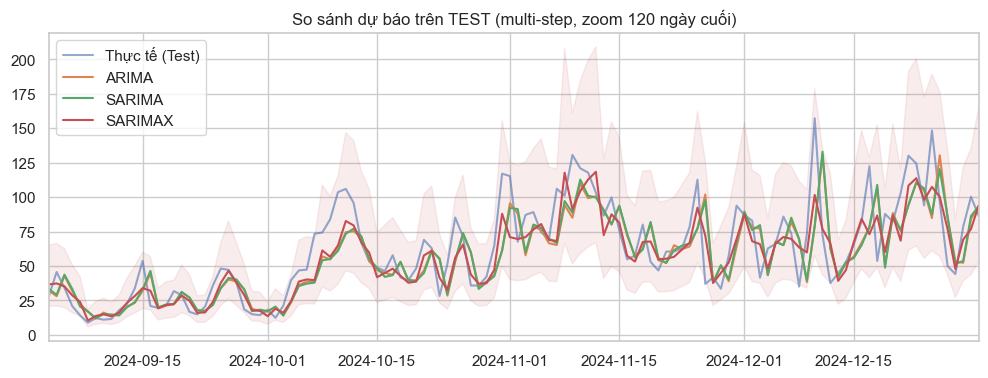

In [9]:
# CELL 9: chạy 3 mô hình, in MAE/RMSE/sMAPE và vẽ so sánh

# 1) Chuẩn bị exog_final theo sel_final từ CELL 7
exog_final = sel_final.copy()

# (tuỳ chọn) nếu muốn chắc chắn có PM10_lag1:
if 'PM10_lag1' in exog_df.columns and 'PM10_lag1' not in exog_final:
    exog_final.append('PM10_lag1')

print("Exog cuối cùng sử dụng:", exog_final)

# 2) Chuẩn hoá exog và align index y_train / y_test
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(exog_df.loc[y_train.index, exog_final])

exog_scaled_all = pd.DataFrame(
    scaler.transform(exog_df[exog_final]),
    index=exog_df.index,
    columns=exog_final
)

exog_scaled_all = exog_scaled_all.replace([np.inf, -np.inf], np.nan)
exog_scaled_all = exog_scaled_all.fillna(method='bfill').fillna(method='ffill')

exog_train_sel = exog_scaled_all.loc[y_train.index] if len(exog_final) > 0 else None
exog_test_sel  = exog_scaled_all.loc[y_test.index]  if len(exog_final) > 0 else None

# 3) ARIMA walk-forward (không exog)
print("Chạy ARIMA walk-forward", order0)
pred_arima, lo_ar, hi_ar, t_ar = forecast_walkforward(
    y_train, y_test,
    order=order0,
    seasonal_order=(0, 0, 0, 0),
    exog_train=None,
    exog_test=None,
    transform=TRANSFORM,
    lam=lam
)

# 4) SARIMA walk-forward (không exog)
seasonal_candidate = seasonal0 if seasonal0 != (0, 0, 0, 0) else (1, 0, 1, 7)
print("Chạy SARIMA walk-forward", order0, seasonal_candidate)
pred_sarima, lo_s, hi_s, t_s = forecast_walkforward(
    y_train, y_test,
    order=order0,
    seasonal_order=seasonal_candidate,
    exog_train=None,
    exog_test=None,
    transform=TRANSFORM,
    lam=lam
)

# 5) SARIMAX walk-forward (có exog)
pred_sarimax = lo_x = hi_x = None
t_x = None

if (exog_train_sel is not None) and (exog_train_sel.shape[1] > 0):
    # Đảm bảo không còn NaN trong exog
    assert exog_train_sel.isna().sum().sum() == 0
    assert exog_test_sel.isna().sum().sum() == 0

    print("Chạy SARIMAX walk-forward với exog")
    pred_sarimax, lo_x, hi_x, t_x = forecast_walkforward(
        y_train, y_test,
        order=order0,
        seasonal_order=seasonal_candidate,
        exog_train=exog_train_sel,
        exog_test=exog_test_sel,
        transform=TRANSFORM,
        lam=lam
    )
else:
    print("Không có exog -> bỏ SARIMAX")

# 6) Tính metric trên thang gốc
y_test_goc = inv_transform(y_test, TRANSFORM, lam)

results = []
results.append({
    'model': 'ARIMA',
    'mae':   mean_absolute_error(y_test_goc, pred_arima),
    'rmse':  rmse(y_test_goc, pred_arima),
    'sMAPE': sMAPE(y_test_goc, pred_arima),
    'time_s': t_ar
})
results.append({
    'model': 'SARIMA',
    'mae':   mean_absolute_error(y_test_goc, pred_sarima),
    'rmse':  rmse(y_test_goc, pred_sarima),
    'sMAPE': sMAPE(y_test_goc, pred_sarima),
    'time_s': t_s
})

if pred_sarimax is not None:
    results.append({
        'model': 'SARIMAX',
        'mae':   mean_absolute_error(y_test_goc, pred_sarimax),
        'rmse':  rmse(y_test_goc, pred_sarimax),
        'sMAPE': sMAPE(y_test_goc, pred_sarimax),
        'time_s': t_x
    })

res_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
print("Bảng so sánh (sắp theo MAE):")
print(res_df)

# 7) Vẽ so sánh (zoom 120 ngày cuối)
plt.figure(figsize=(12, 4))
plt.plot(y_test_goc, label='Thực tế (Test)', color='C0', alpha=0.6)
plt.plot(pred_arima,  label='ARIMA',  color='C1')
plt.plot(pred_sarima, label='SARIMA', color='C2')

if pred_sarimax is not None:
    plt.plot(pred_sarimax, label='SARIMAX', color='C3')
    if (lo_x is not None) and (hi_x is not None):
        plt.fill_between(pred_sarimax.index, lo_x, hi_x, color='C3', alpha=0.1)

plt.legend()
plt.title('So sánh dự báo trên TEST (multi-step, zoom 120 ngày cuối)')
plt.xlim(y_test_goc.index[-120], y_test_goc.index[-1])
plt.show()


In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# RMSE an toàn (tương thích mọi phiên bản sklearn)
def rmse_safe(y_true, y_pred):
    # chuyển về numpy
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # align: nếu có NaN hoặc khác dài, lấy phần đồng thời không-NaN
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

# sMAPE (nếu chưa có)
def sMAPE(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if mask.sum() == 0:
        return np.nan
    yt = y_true[mask]; yp = y_pred[mask]
    return np.mean(2*np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100

# build results an toàn (dùng rmse_safe)
y_test_goc = inv_transform(y_test, TRANSFORM, lam)  # đã có trước

results = []
# đảm bảo pred_* là numpy / series với cùng index; nếu không, dùng .values
for name, pred, t in [('ARIMA', pred_arima, t_ar), ('SARIMA', pred_sarima, t_s)]:
    # align by index if preds are Series
    if hasattr(pred, 'index'):
        # reindex pred to y_test_goc index (won't create leak, chỉ align)
        pred_aligned = pred.reindex(y_test_goc.index)
    else:
        pred_aligned = pd.Series(pred, index=y_test_goc.index)

    mae = mean_absolute_error(y_test_goc.values, pred_aligned.values)
    rm = rmse_safe(y_test_goc.values, pred_aligned.values)
    sm = sMAPE(y_test_goc.values, pred_aligned.values)
    results.append({'model':name, 'mae':mae, 'rmse':rm, 'sMAPE':sm, 'time_s':t})

# nếu bạn có pred_sarimax, thêm tương tự
if 'pred_sarimax' in globals() and pred_sarimax is not None:
    pred = pred_sarimax
    if hasattr(pred, 'index'):
        pred_aligned = pred.reindex(y_test_goc.index)
    else:
        pred_aligned = pd.Series(pred, index=y_test_goc.index)
    mae = mean_absolute_error(y_test_goc.values, pred_aligned.values)
    rm = rmse_safe(y_test_goc.values, pred_aligned.values)
    sm = sMAPE(y_test_goc.values, pred_aligned.values)
    results.append({'model':'SARIMAX','mae':mae,'rmse':rm,'sMAPE':sm,'time_s':t_x})

res_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
print("Bảng so sánh (sắp theo MAE):")
print(res_df)


Bảng so sánh (sắp theo MAE):
     model        mae       rmse      sMAPE      time_s
0  SARIMAX  11.427771  15.954016  22.131170  676.508292
1   SARIMA  15.335615  21.256166  28.801482   87.356985
2    ARIMA  15.372079  21.401862  28.791032   12.110202


Model tốt nhất: SARIMAX MAE: 11.427771138179732
                                      SARIMAX Results                                       
Dep. Variable:                                 PM25   No. Observations:                  584
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 30)   Log Likelihood                -100.167
Date:                              Fri, 21 Nov 2025   AIC                            230.334
Time:                                      13:12:56   BIC                            294.983
Sample:                                  01-01-2023   HQIC                           255.598
                                       - 08-06-2024                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
PM10               0.2044      0.007     2

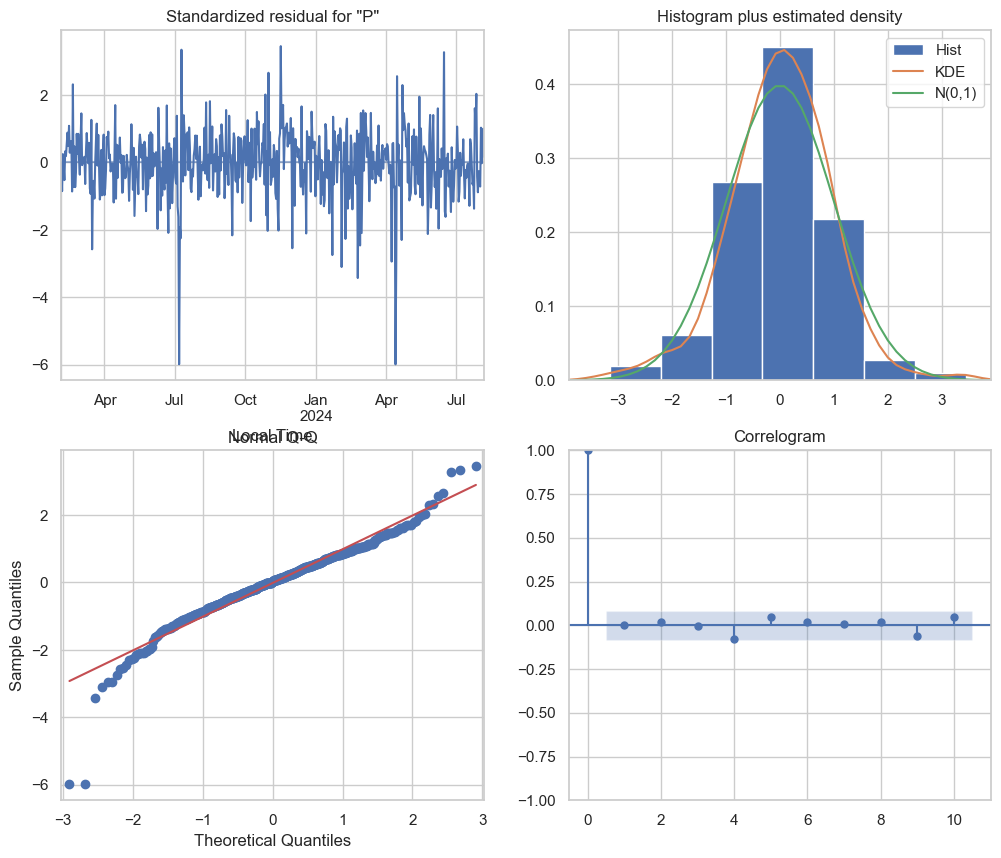

Ljung-Box p(12): 0.5073103469627278
Jarque-Bera p: 0.0 skew: 2.419447209303574 kurtosis: 41.220675211214925


In [11]:
  # CELL 10: diagnostics cho model tốt nhất và lưu model + kết quả
best = res_df.iloc[0]
print("Model tốt nhất:", best['model'], "MAE:", best['mae'])

# Fit lại final model trên y_train (transform)
if best['model'] == 'ARIMA':
    model_final = SARIMAX(y_train, order=order0, seasonal_order=(0,0,0,0),
                          enforce_stationarity=False, enforce_invertibility=False)
elif best['model'] == 'SARIMA':
    model_final = SARIMAX(y_train, order=order0, seasonal_order=seasonal_candidate,
                          enforce_stationarity=False, enforce_invertibility=False)
else:  # SARIMAX
    model_final = SARIMAX(y_train, exog=exog_train_sel, order=order0, seasonal_order=seasonal_candidate,
                          enforce_stationarity=False, enforce_invertibility=False)

res_final = model_final.fit(disp=False)
print(res_final.summary())

# Vẽ diagnostics (residuals)
res_final.plot_diagnostics(figsize=(12,10))
plt.show()

# Kiểm Ljung-Box và Jarque-Bera để kiểm residual
p_lb = float(acorr_ljungbox(res_final.resid.dropna(), lags=[12], return_df=True)["lb_pvalue"].iloc[0])
jb_stat, jb_p, skew, kurt = jarque_bera(res_final.resid.dropna())
print("Ljung-Box p(12):", p_lb)
print("Jarque-Bera p:", jb_p, "skew:", skew, "kurtosis:", kurt)



In [12]:
# Giả sử đây là cấu hình bạn đã chọn là tốt nhất
best_order     = (1, 1, 2)
best_seasonal  = (0, 0, 1, 30)
best_transform = TRANSFORM     # 'log' hoặc gì bạn đang dùng
best_lam       = lam           # nếu dùng boxcox thì giữ lambda
best_exog_cols = exog_final    # danh sách cột exog cuối cùng
best_scaler    = scaler        # StandardScaler đã fit trên exog_train

# Fit lại SARIMAX trên TOÀN BỘ dữ liệu huấn luyện (ví dụ y_train)
y_train_tf, _ = transform_series(y_train, method=best_transform)

best_model = SARIMAX(
    y_train_tf,
    exog=exog_train_sel[best_exog_cols],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_res = best_model.fit(maxiter=200, disp=False)


In [13]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib, json
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

from utils_pm25 import build_pm25_daily, build_exog_daily, transform_series

# 1) Build lại PM25 theo ngày cho toàn bộ 2023–2024
df = pd.read_csv("E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv")
pm25_daily = build_pm25_daily(df)
y_full = pm25_daily.copy()          # y dùng để train FULL

# 2) Build exog theo ngày, align với y_full
exog_daily = build_exog_daily(df, y_full.index)

# 3) Lấy đúng exog_cols tốt nhất bạn đã tìm được
exog_full = exog_daily[best_exog_cols].copy()

# 4) Fit scaler trên FULL exog (khác với lúc train/test 8/2)
full_scaler = StandardScaler()
full_scaler.fit(exog_full)

exog_full_scaled = pd.DataFrame(
    full_scaler.transform(exog_full),
    index=exog_full.index,
    columns=best_exog_cols
)

# 5) Transform y theo đúng method
y_full_tf, lam_new = transform_series(y_full, method=best_transform)

# Nếu bạn muốn giữ lại lam từ tuning thì:
# lam_final = best_lam
# Còn nếu bạn muốn lam mới thì:
lam_final = lam_new

# 6) Fit SARIMAX trên 100% dữ liệu
best_model = SARIMAX(
    y_full_tf,
    exog=exog_full_scaled,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_res = best_model.fit(maxiter=200, disp=False)

# 7) Save model, scaler và config đúng thư mục PROJECT_1/models
root = Path.cwd().parent           # nếu notebook nằm trong src/
model_dir = root / "models"
model_dir.mkdir(exist_ok=True)

joblib.dump(best_res, model_dir / "sarimax_pm25.pkl")
joblib.dump(full_scaler, model_dir / "exog_scaler.pkl")

config = {
    "order": best_order,
    "seasonal_order": best_seasonal,
    "transform": best_transform,
    "lam": float(lam_final) if lam_final is not None else None,
    "exog_cols": best_exog_cols
}
with open(model_dir / "config_pm25.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("✔ Đã lưu model FULL vào:", model_dir)


✔ Đã lưu model FULL vào: E:\Document\PROJECT_1\models
